## Data Preprocessing, Loading and Splitting

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DATASET DEFINITION
# ---------------------------------------------------------
class FruitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Directory {root_dir} not found.")

        self.class_names = sorted([f for f in os.listdir(root_dir)
                                   if os.path.isdir(os.path.join(root_dir, f))])

        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}

        for class_idx, class_name in enumerate(self.class_names):
            class_dir = os.path.join(root_dir, class_name)
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(class_dir, img_file))
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Wrapper to apply transforms after splitting
class ApplyTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

# ---------------------------------------------------------
# 2. CONFIGURATION & TRANSFORMS
# ---------------------------------------------------------
dataset_path = 'FRUIT-16K'

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 3. DATA LOADING & SPLITTING
# ---------------------------------------------------------
print("--- Loading Dataset ---")
base_dataset = FruitDataset(dataset_path, transform=None)
print(f"Total images found: {len(base_dataset)}")
print(f"Classes identified: {base_dataset.class_names}")

train_size = int(0.7 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    base_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n--- Split Summary ---")
print(f"Train set: {len(train_subset)} images")
print(f"Val set:   {len(val_subset)} images")
print(f"Test set:  {len(test_subset)} images")

train_loader = DataLoader(ApplyTransform(train_subset, train_transform), batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(ApplyTransform(val_subset, test_transform), batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(ApplyTransform(test_subset, test_transform), batch_size=32, shuffle=False, num_workers=0)

--- Loading Dataset ---
Total images found: 16000
Classes identified: ['F_Banana', 'F_Lemon', 'F_Lulo', 'F_Mango', 'F_Orange', 'F_Strawberry', 'F_Tamarillo', 'F_Tomato', 'S_Banana', 'S_Lemon', 'S_Lulo', 'S_Mango', 'S_Orange', 'S_Strawberry', 'S_Tamarillo', 'S_Tomato']

--- Split Summary ---
Train set: 11200 images
Val set:   2400 images
Test set:  2400 images


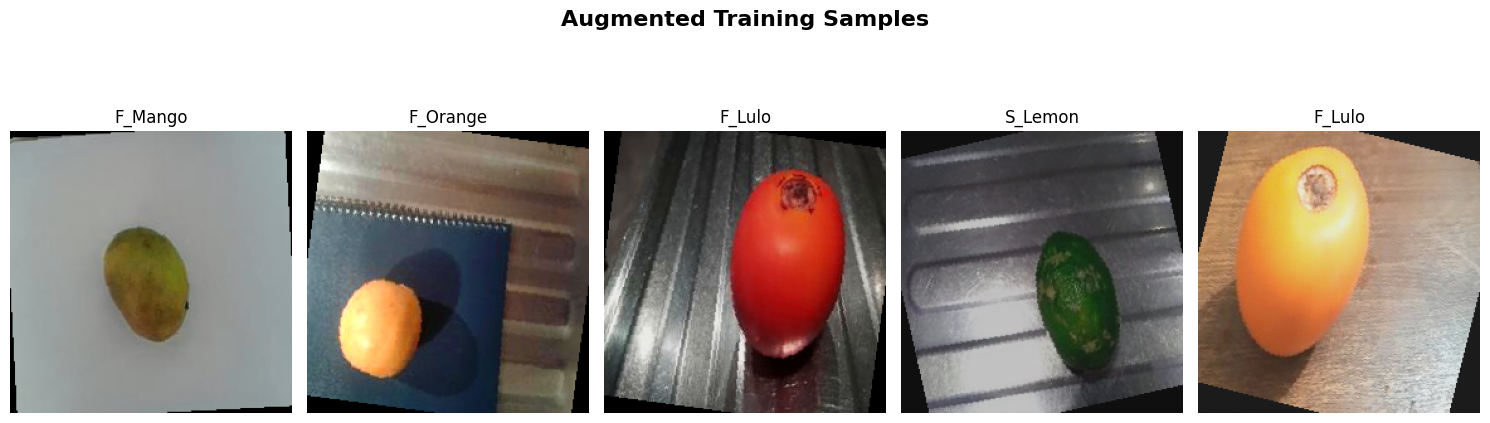

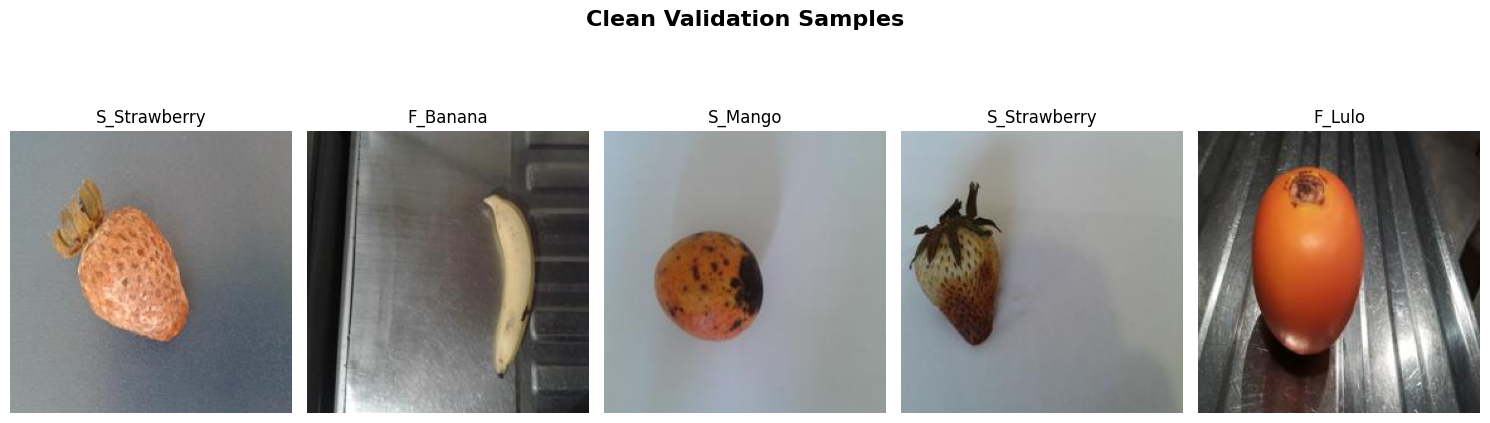

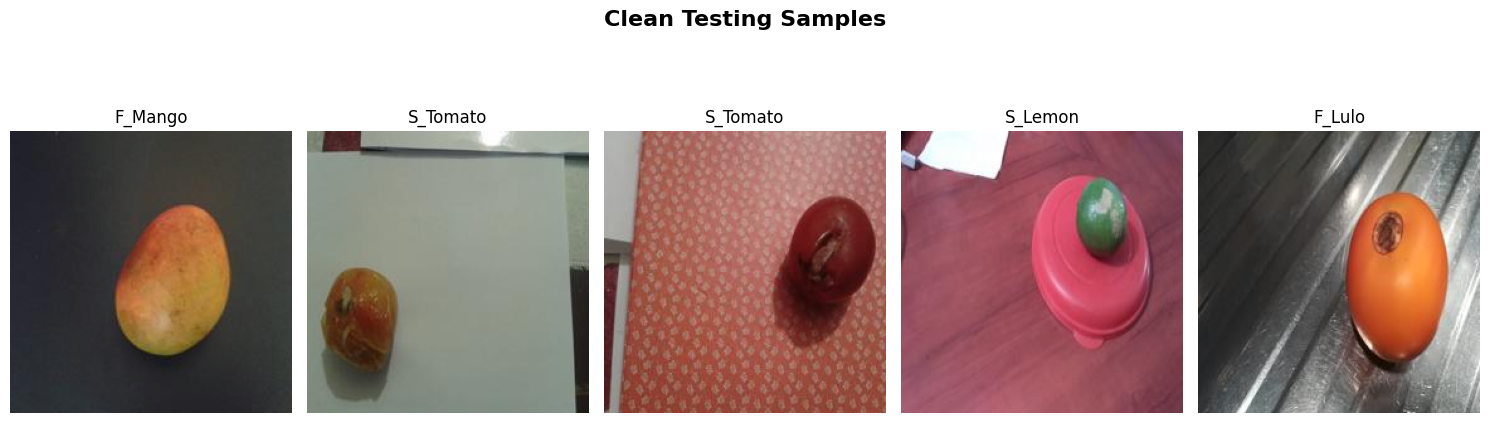

In [ ]:

def show_samples(loader, title, class_names, n=5):
    # Grab one batch
    images, labels = next(iter(loader))

    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=16, fontweight='bold')

    for i in range(min(n, images.size(0))):
        img = images[i].cpu()

        # Denormalize using the same mean/std used in transforms
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean

        img = torch.clamp(img, 0, 1)
        img_np = img.permute(1, 2, 0).numpy()

        plt.subplot(1, n, i+1)
        plt.imshow(img_np)

        # Use base_dataset.class_names to get the original label (e.g., 'F_Apple')
        class_name = class_names[labels[i].item()]
        plt.title(class_name, fontsize=12)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Ensure base_dataset.class_names is passed correctly
show_samples(train_loader, "Augmented Training Samples", base_dataset.class_names)
show_samples(val_loader, "Clean Validation Samples", base_dataset.class_names)
show_samples(test_loader, "Clean Testing Samples", base_dataset.class_names)

### Binary CNN Model Definition
We will define a simple CNN with 3 convolutional layers and a fully connected layer. We also need a helper to map the 16 original classes to binary labels: `Fresh` (0) or `Spoiled` (1).

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Deeper feature extraction
        self.features = nn.Sequential(
            self._block(3, 32),   # 112x112
            self._block(32, 64),  # 56x56
            self._block(64, 128), # 28x28
            self._block(128, 256) # 14x14
        )
        # Global Average Pooling reduces 256x14x14 to 256x1x1
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 2) # Binary output
        )

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f"Model initialized on {device}")

Model initialized on cuda


### Training and Validation Loop
Now we define the loss function and optimizer, then train the model. We convert the multi-class labels to binary labels on the fly during training.

In [ ]:
def get_binary_label(label_idx, dataset):
    class_name = dataset.class_names[label_idx]
    return 0 if class_name.startswith('F_') else 1

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

def train_model(epochs, early_stop_patience=7):
    class_to_binary = torch.tensor([get_binary_label(i, base_dataset) for i in range(len(base_dataset.class_names))], device=device)
    best_val_acc = 0.0
    epochs_no_improve = 0

    print(f"--- Model initialized on {device}. Starting Training ---")

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device)
            binary_labels = class_to_binary[labels]

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, binary_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += binary_labels.size(0)
            correct += predicted.eq(binary_labels).sum().item()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device)
                binary_labels = class_to_binary[labels]
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += binary_labels.size(0)
                val_correct += predicted.eq(binary_labels).sum().item()

        train_acc, val_acc = 100.*correct/total, 100.*val_correct/val_total
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(train_loader):.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | LR: {current_lr:.6f}")

        # Scheduler and Early Stopping Logic
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"--> New Best Acc: {best_val_acc:.2f}% (Saved)")
        else:
            epochs_no_improve += 1
            print(f"--> No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= early_stop_patience:
            print("\n[!] Early Stopping Triggered. Ending Training.")
            break

    print(f"\nTraining Complete. Best Val Accuracy: {best_val_acc:.2f}%")

train_model(epochs=40, early_stop_patience=8)

--- Model initialized on cuda. Starting Training ---
Epoch 01 | Loss: 0.6528 | Train: 61.22% | Val: 69.46% | LR: 0.001000
--> New Best Acc: 69.46% (Saved)
Epoch 02 | Loss: 0.5942 | Train: 68.01% | Val: 76.54% | LR: 0.001000
--> New Best Acc: 76.54% (Saved)
Epoch 03 | Loss: 0.5508 | Train: 71.66% | Val: 77.79% | LR: 0.001000
--> New Best Acc: 77.79% (Saved)
Epoch 04 | Loss: 0.5195 | Train: 74.53% | Val: 78.08% | LR: 0.001000
--> New Best Acc: 78.08% (Saved)
Epoch 05 | Loss: 0.4928 | Train: 76.60% | Val: 73.75% | LR: 0.001000
--> No improvement for 1 epoch(s)
Epoch 06 | Loss: 0.4698 | Train: 78.05% | Val: 73.29% | LR: 0.001000
--> No improvement for 2 epoch(s)
Epoch 07 | Loss: 0.4389 | Train: 80.06% | Val: 84.96% | LR: 0.001000
--> New Best Acc: 84.96% (Saved)
Epoch 08 | Loss: 0.4159 | Train: 81.37% | Val: 86.67% | LR: 0.001000
--> New Best Acc: 86.67% (Saved)
Epoch 09 | Loss: 0.3930 | Train: 82.72% | Val: 87.92% | LR: 0.001000
--> New Best Acc: 87.92% (Saved)
Epoch 10 | Loss: 0.3566 | T

--- Starting Test Set Evaluation ---

FINAL TEST ACCURACY: 98.83%
Total Test Images: 2400
Correct Predictions: 2372
Errors: 28


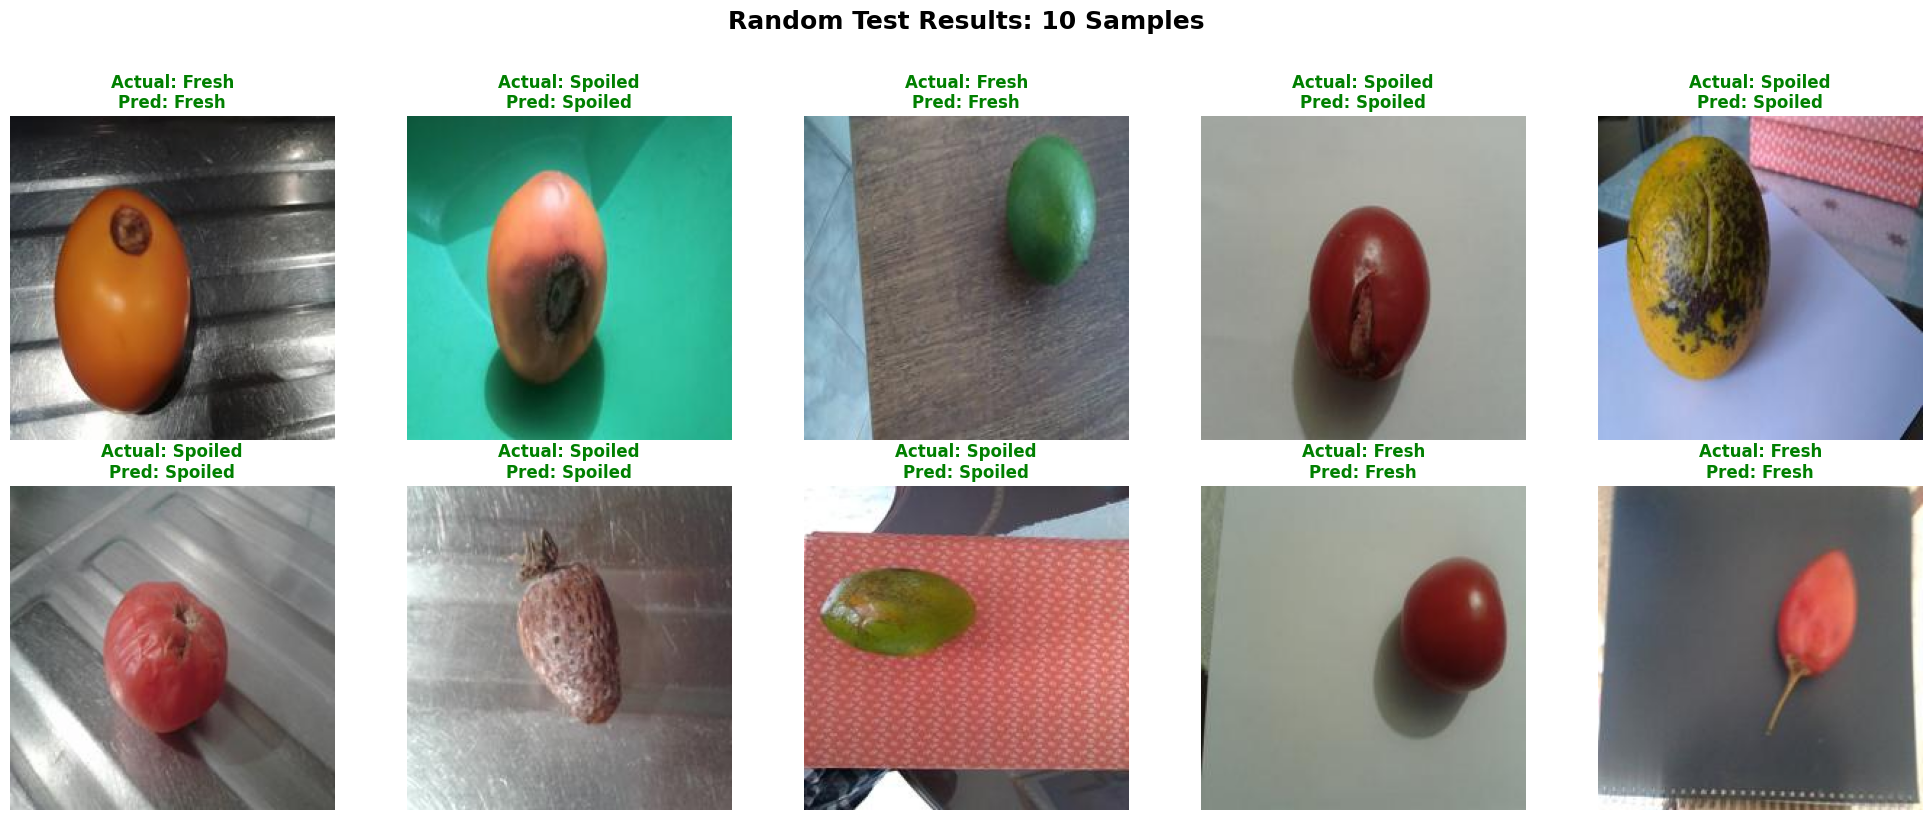

In [ ]:
import torch

def evaluate_test_set():
    # 1. Load the best saved weights
    # Make sure the filename matches what you saved (best_model.pt)
    model.load_state_dict(torch.load('best_model.pt'))
    model.eval()

    # 2. Setup binary mapping
    class_to_binary = torch.tensor(
        [get_binary_label(i, base_dataset) for i in range(len(base_dataset.class_names))],
        device=device
    )

    test_correct = 0
    test_total = 0

    print("--- Starting Test Set Evaluation ---")

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            binary_labels = class_to_binary[labels]

            outputs = model(images)
            _, predicted = outputs.max(1)

            test_total += binary_labels.size(0)
            test_correct += predicted.eq(binary_labels).sum().item()

    final_test_acc = 100. * test_correct / test_total
    print(f"\nFINAL TEST ACCURACY: {final_test_acc:.2f}%")
    print(f"Total Test Images: {test_total}")
    print(f"Correct Predictions: {test_correct}")
    print(f"Errors: {test_total - test_correct}")

# Helper to visualize specific test results
def visualize_predictions(n=10):
    model.eval()

    # 1. Get 10 random indices from the test subset
    total_test_images = len(test_subset)
    random_indices = torch.randperm(total_test_images)[:n].tolist()

    # 2. Get the binary mapping
    class_to_binary = torch.tensor([get_binary_label(i, base_dataset) for i in range(len(base_dataset.class_names))])

    # Setup plot (2 rows of 5 for better visibility)
    plt.figure(figsize=(20, 8))
    plt.suptitle(f"Random Test Results: 10 Samples", fontsize=18, fontweight='bold', y=1.02)

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            # Get image and label directly from the subset (ApplyTransform handles the resize/tensor)
            # We use the test_subset with test_transform applied via our ApplyTransform wrapper
            img_tensor, label_idx = ApplyTransform(test_subset, test_transform)[idx]

            # Prepare for model (add batch dimension)
            input_tensor = img_tensor.unsqueeze(0).to(device)

            # Predict
            outputs = model(input_tensor)
            _, predicted = outputs.max(1)

            # Labels
            actual_idx = class_to_binary[label_idx].item()
            pred_idx = predicted.item()

            actual_label = "Fresh" if actual_idx == 0 else "Spoiled"
            pred_label = "Fresh" if pred_idx == 0 else "Spoiled"
            color = 'green' if actual_idx == pred_idx else 'red'

            # Denormalize image for plotting
            img_show = img_tensor.cpu()
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_show = img_show * std + mean
            img_show = torch.clamp(img_show, 0, 1).permute(1, 2, 0).numpy()

            # Plot
            plt.subplot(2, 5, i + 1)
            plt.imshow(img_show)
            plt.title(f"Actual: {actual_label}\nPred: {pred_label}", color=color, fontsize=12, fontweight='bold')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the evaluation
evaluate_test_set()
visualize_predictions()

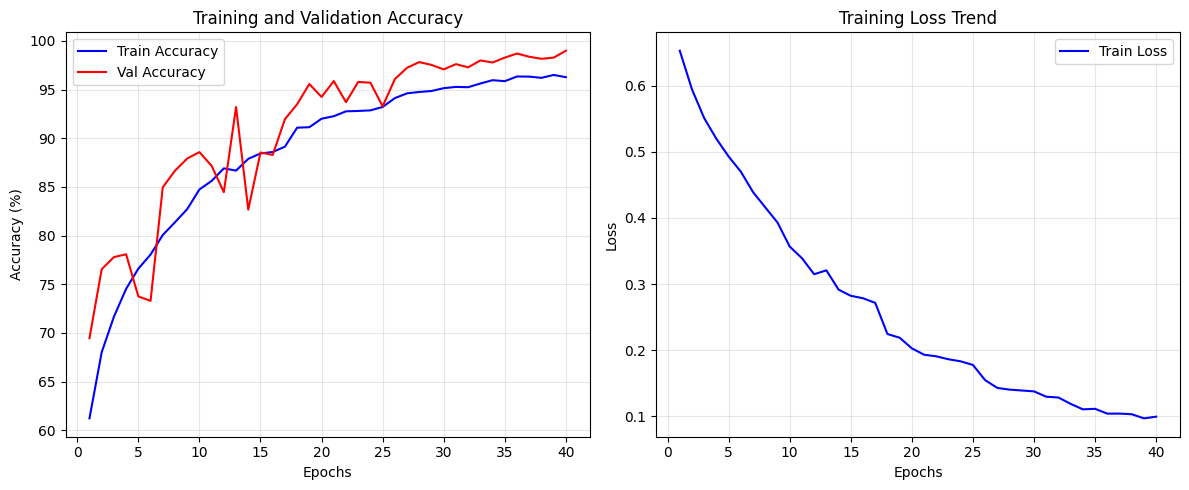

In [ ]:
import matplotlib.pyplot as plt

# Manually extracted data from the console output
history = {
    'train_acc': [61.22, 68.01, 71.66, 74.53, 76.60, 78.05, 80.06, 81.37, 82.72, 84.74,
                  85.62, 86.91, 86.68, 87.89, 88.44, 88.59, 89.14, 91.09, 91.14, 92.01,
                  92.27, 92.77, 92.81, 92.87, 93.22, 94.13, 94.62, 94.76, 94.86, 95.15,
                  95.28, 95.25, 95.63, 95.97, 95.87, 96.35, 96.34, 96.21, 96.51, 96.28],

    'val_acc':   [69.46, 76.54, 77.79, 78.08, 73.75, 73.29, 84.96, 86.67, 87.92, 88.58,
                  87.17, 84.46, 93.21, 82.67, 88.54, 88.29, 91.96, 93.50, 95.58, 94.25,
                  95.88, 93.71, 95.79, 95.71, 93.29, 96.08, 97.25, 97.83, 97.54, 97.08,
                  97.62, 97.29, 98.00, 97.79, 98.29, 98.71, 98.38, 98.17, 98.29, 99.00],

    'train_loss': [0.6528, 0.5942, 0.5508, 0.5195, 0.4928, 0.4698, 0.4389, 0.4159, 0.3930, 0.3566,
                   0.3391, 0.3148, 0.3207, 0.2915, 0.2822, 0.2785, 0.2715, 0.2244, 0.2188, 0.2027,
                   0.1931, 0.1907, 0.1862, 0.1831, 0.1776, 0.1546, 0.1429, 0.1403, 0.1390, 0.1377,
                   0.1296, 0.1284, 0.1188, 0.1105, 0.1113, 0.1040, 0.1041, 0.1031, 0.0969, 0.0994]
}

def plot_manual_history(hist):
    epochs = range(1, len(hist['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['train_acc'], 'b-', label='Train Accuracy')
    plt.plot(epochs, hist['val_acc'], 'r-', label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['train_loss'], 'b-', label='Train Loss')
    plt.title('Training Loss Trend')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_manual_history(history)